# 03 — Modelado y Evaluación

Compara tres modelos de regresión para predecir `ac_annual` (kWh/año).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

DATA_PROC = Path('../data/processed')
MODELS_DIR = Path('../src/models')
MODELS_DIR.mkdir(exist_ok=True)

## 1. Cargar datos

In [2]:
df = pd.read_csv(DATA_PROC / 'solar_chile_model.csv')

FEATURES = [
    'system_size_kw', 'tilt', 'azimuth', 'losses',
    'tilt_deviation', 'azimuth_deviation',
    'latitude', 'solrad_annual',
]
TARGET = 'ac_annual'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}  Test: {X_test.shape}')

Train: (2400, 8)  Test: (600, 8)


## 2. Baseline — Regresión Lineal

In [3]:
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

r2_lr   = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f'Linear Regression  R²={r2_lr:.4f}  RMSE={rmse_lr:.1f} kWh')

Linear Regression  R²=0.9753  RMSE=810.5 kWh


## 3. Random Forest

In [4]:
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])
pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)

r2_rf   = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f'Random Forest      R²={r2_rf:.4f}  RMSE={rmse_rf:.1f} kWh')

Random Forest      R²=0.9936  RMSE=411.1 kWh


## 4. Gradient Boosting + GridSearchCV

In [5]:
param_grid = {
    'model__n_estimators':  [100, 200],
    'model__max_depth':     [3, 5],
    'model__learning_rate': [0.05, 0.1],
}
pipe_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingRegressor(random_state=42))
])
gs = GridSearchCV(pipe_gb, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)

y_pred_gb = gs.predict(X_test)
r2_gb   = r2_score(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print(f'Mejores params: {gs.best_params_}')
print(f'Gradient Boosting  R²={r2_gb:.4f}  RMSE={rmse_gb:.1f} kWh')

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Mejores params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}
Gradient Boosting  R²=0.9984  RMSE=204.9 kWh


## 5. Comparación de modelos

In [6]:
results = pd.DataFrame({
    'Modelo':      ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'R²':          [r2_lr, r2_rf, r2_gb],
    'RMSE (kWh)':  [rmse_lr, rmse_rf, rmse_gb],
})
results.sort_values('R²', ascending=False).round(4)

,Modelo,R²,RMSE (kWh)
2,Gradient Boosting,0.9984,204.8906
1,Random Forest,0.9936,411.1218
0,Linear Regression,0.9753,810.4915


## 6. Feature Importance

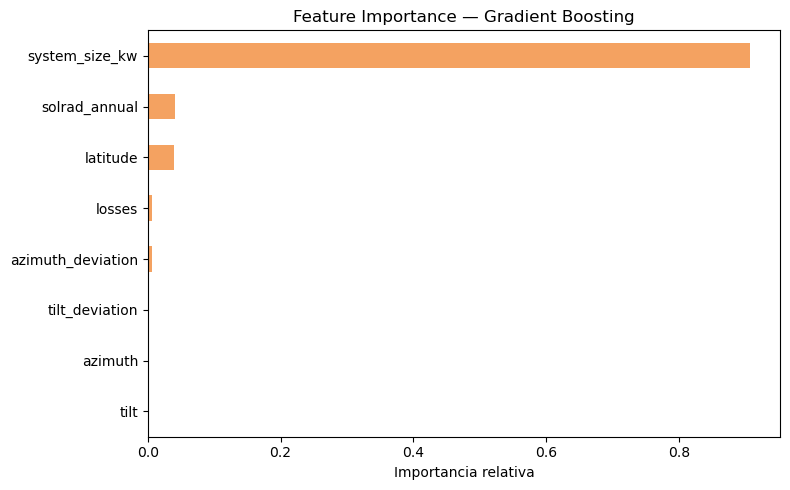

In [7]:
best_model = gs.best_estimator_['model']
importances = pd.Series(
    best_model.feature_importances_, index=FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot.barh(ax=ax, color='#f4a261')
ax.set_title('Feature Importance — Gradient Boosting')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()

## 7. Predicho vs Real

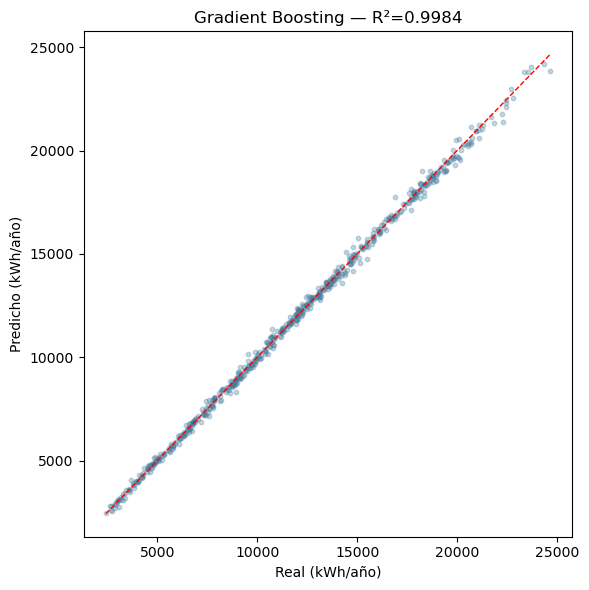

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_gb, alpha=0.3, s=10, color='#457b9d')
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, 'r--', linewidth=1)
ax.set_xlabel('Real (kWh/año)')
ax.set_ylabel('Predicho (kWh/año)')
ax.set_title(f'Gradient Boosting — R²={r2_gb:.4f}')
plt.tight_layout()

## 8. Guardar modelo

In [9]:
model_path = MODELS_DIR / 'gb_energy_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(gs.best_estimator_, f)

print(f'Modelo guardado en {model_path}')

Modelo guardado en ../src/models/gb_energy_model.pkl
